# Exercise 10: Dynamic Processes on Networks

**Topic:** Terrorist Relationship Network (TerroristRel dataset)  
**Goal:** Simulate a simple dynamic process (information or ideology spread) on the network and study how its structure affects the outcome.

In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from pathlib import Path
import random

# Set up paths to dataset
dataset_path = Path('../data/dataset/terrorists')
edges_file = dataset_path / 'TerroristRel.edges'

# Load edges
edges = []
with open(edges_file, 'r') as f:
    for line in f:
        parts = line.strip().split('\t')
        if len(parts) == 2:
            edges.append((parts[0], parts[1]))

G = nx.Graph()
G.add_edges_from(edges)

N = G.number_of_nodes()
print(f"Network size: N={N}")

Network size: N=881


## Task 1: Model Description (Independent Cascade)
We use an **Independent Cascade (IC)** model to simulate the spread of a "radical ideology" or operational instruction. 
- Each active node has one chance to activate its inactive neighbors with a probability $p$.
- Initial state: A few "seed" nodes are active.

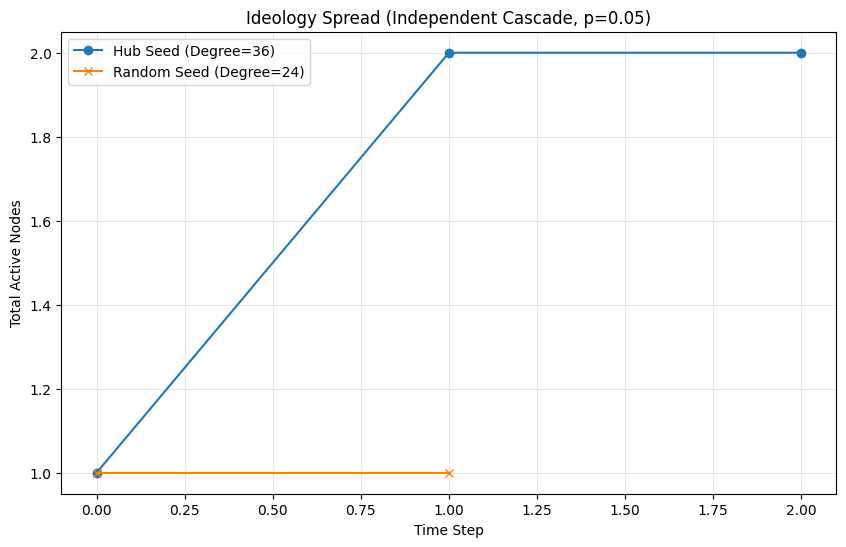

In [2]:
def independent_cascade(G, seeds, p=0.1):
    active = set(seeds)
    newly_active = set(seeds)
    history = [len(active)]
    
    while newly_active:
        next_active = set()
        for u in newly_active:
            for v in G.neighbors(u):
                if v not in active:
                    if random.random() < p:
                        next_active.add(v)
        
        active.update(next_active)
        newly_active = next_active
        history.append(len(active))
        
    return history

# Identify a central seed (highest degree hub)
hub_node = max(dict(G.degree()).items(), key=lambda x: x[1])[0]
random_node = random.choice(list(G.nodes()))

p_spread = 0.05
hist_hub = independent_cascade(G, [hub_node], p_spread)
hist_random = independent_cascade(G, [random_node], p_spread)

plt.figure(figsize=(10, 6))
plt.plot(hist_hub, label=f'Hub Seed (Degree={G.degree(hub_node)})', marker='o')
plt.plot(hist_random, label=f'Random Seed (Degree={G.degree(random_node)})', marker='x')
plt.xlabel('Time Step')
plt.ylabel('Total Active Nodes')
plt.title(f'Ideology Spread (Independent Cascade, p={p_spread})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('cascade_simulation.png', dpi=150)
plt.show()

## Interpretation

The simulation results show that:
1. **Hub Influence:** Starting the spread from a central hub (like OBL) leads to a much faster and more extensive cascade. The hub's high connectivity allows the "message" to reach many local cells simultaneously, triggering secondary cascades.
2. **Random Start:** Starting from a random peripheral node often results in a very limited spread, as the cascade may fail to reach a hub that could amplify it.
3. **Network Structure:** The presence of hubs and a small-world structure (short paths) significantly accelerates the diffusion process across the terrorist network. This explains why central figures are so vital for operational coordination and ideological propagation.